In [1]:
# --- STEP 1: IMPORTS ---
# Shared by ALL three models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

# Model-specific imports
from sklearn.linear_model import LogisticRegression            # Model 1
from sklearn.svm import SVC                                    # Model 2
from sklearn.decomposition import PCA                          # Model 2
from sklearn.inspection import permutation_importance          # Model 2 & 3
from sklearn.neighbors import KNeighborsClassifier             # Model 3

print('All imports successful.')


All imports successful.


In [2]:
# --- STEP 2: LOAD DATASET -------------
# Shared by ALL three models

df = pd.read_csv('wisc_bc_data.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())

print('\nClass distribution:')
print(df['diagnosis'].value_counts())

print('\nMissing values per column:')
print(df.isnull().sum().sum(), 'total missing values')


Dataset Shape: (569, 32)

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0  87139402         B        12.32         12.39           78.85      464.1   
1   8910251         B        10.60         18.95           69.28      346.4   
2    905520         B        11.04         16.83           70.92      373.2   
3    868871         B        11.28         13.39           73.00      384.8   
4   9012568         B        15.19         13.21           97.65      711.8   

   smoothness_mean  compactness_mean  concavity_mean  points_mean  ...  \
0          0.10280           0.06981         0.03987      0.03700  ...   
1          0.09688           0.11470         0.06387      0.02642  ...   
2          0.10770           0.07804         0.03046      0.02480  ...   
3          0.11640           0.11360         0.04635      0.04796  ...   
4          0.07963           0.06934         0.03393      0.02657  ...   

   radius_worst  texture_worst  perimete

In [4]:
# --- STEP 3: PREPROCESSING ----------------
# Shared by ALL three models
#
# Split strategy  (same random_state=42 for reproducibility):
#   Full dataset  →  80% train+val  |  20% test
#   train+val     →  75% train      |  25% val
#   Result        →  60% train  |  20% val  |  20% test

# Drop irrelevant columns
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# Encode target: B=0 (Benign), M=1 (Malignant)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

# Features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# - 1. Hold out test set (20 %) ------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---- 2. Split remainder into train (75 %) and val (25 %) ---- 
#       0.75 × 0.80 = 0.60  →  60 % train of full dataset
#       0.25 × 0.80 = 0.20  →  20 % val  of full dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# ---- 3. Fit scaler on TRAIN only; transform val & test ---- 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Also keep a full-dataset scaled version for cross-validation utilities
X_scaled = scaler.fit_transform(X)   # re-fit on all for CV only

feature_names = X.columns.tolist()

print(f'Total samples    : {len(y)}')
print(f'Training samples : {X_train_scaled.shape[0]}  ({X_train_scaled.shape[0]/len(y)*100:.0f} %)')
print(f'Validation samples: {X_val_scaled.shape[0]}   ({X_val_scaled.shape[0]/len(y)*100:.0f} %)')
print(f'Test samples     : {X_test_scaled.shape[0]}   ({X_test_scaled.shape[0]/len(y)*100:.0f} %)')
print(f'Number of features: {X_train_scaled.shape[1]}')


Total samples    : 569
Training samples : 341  (60 %)
Validation samples: 114   (20 %)
Test samples     : 114   (20 %)
Number of features: 30


In [5]:
# -- MODEL 1: LOGISTIC REGRESSION -- TRAIN ------

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

print('[Model 1 — Logistic Regression] Training complete.')

[Model 1 — Logistic Regression] Training complete.


In [6]:
# ---- MODEL 1: LOGISTIC REGRESSION -- EVALUATE (VAL + TEST) ----

def print_metrics(model_name, y_true, y_pred, split_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    print(f'[{model_name}] {split_name} Set')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-score  : {f1:.4f}')
    print()
    return acc, prec, rec, f1

# Validation
y_val_pred_lr  = lr_model.predict(X_val_scaled)
lr_val_acc, lr_val_prec, lr_val_rec, lr_val_f1 = print_metrics(
    'Model 1 — Logistic Regression', y_val, y_val_pred_lr, 'Validation'
)

# Test
y_pred_lr = lr_model.predict(X_test_scaled)
lr_acc, lr_prec, lr_rec, lr_f1 = print_metrics(
    'Model 1 — Logistic Regression', y_test, y_pred_lr, 'Test'
)


[Model 1 — Logistic Regression] Validation Set
  Accuracy  : 0.9561
  Precision : 1.0000
  Recall    : 0.8837
  F1-score  : 0.9383

[Model 1 — Logistic Regression] Test Set
  Accuracy  : 0.9912
  Precision : 1.0000
  Recall    : 0.9762
  F1-score  : 0.9880



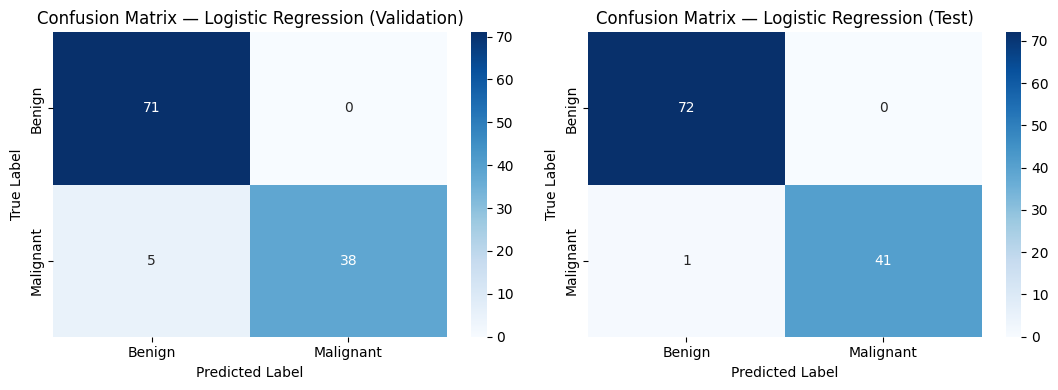

In [7]:
# ----- MODEL 1: LOGISTIC REGRESSION — CONFUSION MATRIX (VAL & TEST) -----

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_val,  y_test],
    [y_val_pred_lr, y_pred_lr],
    ['Validation', 'Test']
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'Confusion Matrix — Logistic Regression ({title})')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()


In [8]:
# ── MODEL 1: LOGISTIC REGRESSION — CROSS-VALIDATION ───────────────────────────

cv_scores_lr = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                X_scaled, y, cv=5)

print('[Model 1 — Logistic Regression] 5-Fold Cross-Validation')
print(f'  CV scores : {cv_scores_lr}')
print(f'  Mean CV   : {cv_scores_lr.mean():.4f}')


[Model 1 — Logistic Regression] 5-Fold Cross-Validation
  CV scores : [0.93859649 0.97368421 0.98245614 0.97368421 1.        ]
  Mean CV   : 0.9737


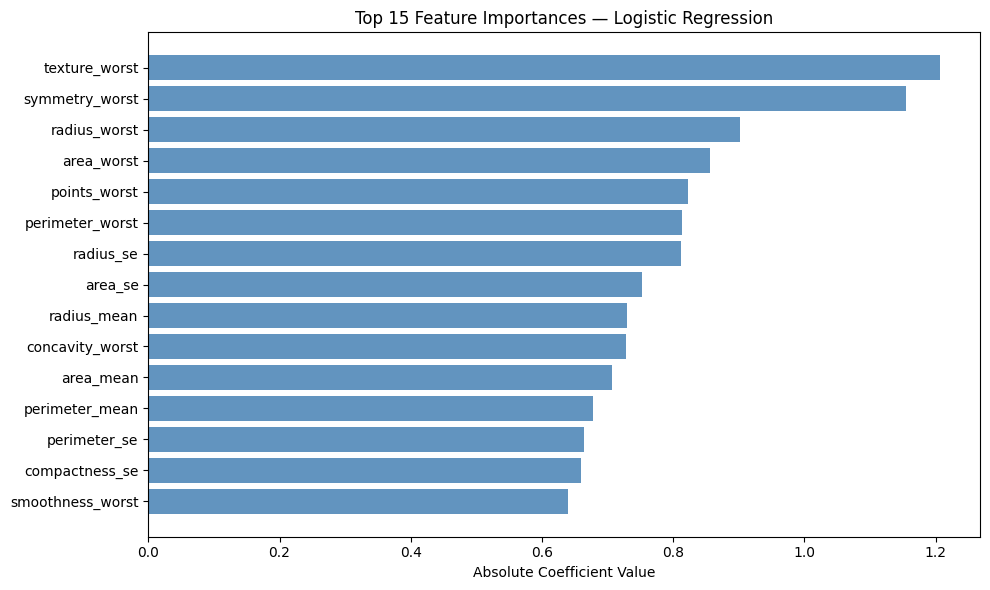

In [9]:
# ------ MODEL 1: LOGISTIC REGRESSION — FEATURE IMPORTANCE ------ 
# Logistic Regression has direct feature coefficients.
# Larger absolute coefficient = greater influence on the prediction.

coefficients  = np.abs(lr_model.coef_[0])         # absolute value of coefficients
sorted_idx_lr = np.argsort(coefficients)[::-1]     # descending order
top_n         = 15

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in sorted_idx_lr[:top_n]][::-1],
    coefficients[sorted_idx_lr[:top_n]][::-1],
    color='steelblue', alpha=0.85
)
plt.xlabel('Absolute Coefficient Value')
plt.title(f'Top {top_n} Feature Importances — Logistic Regression')
plt.tight_layout()
plt.show()


In [10]:
# -----MODEL 2: SVM + PCA — FIT PCA (on TRAIN only) -----
# n_components=0.95: keep enough PCs to explain at least 95 % of variance.
# IMPORTANT: PCA is fit on X_train_scaled only to prevent data leakage.

pca_95 = PCA(n_components=0.95, random_state=42)
X_pca_train = pca_95.fit_transform(X_train_scaled)
X_pca_val   = pca_95.transform(X_val_scaled)
X_pca_test  = pca_95.transform(X_test_scaled)

# For cross-validation only (fit on all data)
pca_cv = PCA(n_components=0.95, random_state=42)
X_pca_all = pca_cv.fit_transform(X_scaled)

print('[Model 2 — SVM + PCA] PCA fitting complete.')
print(f'  Original features  : {X_train_scaled.shape[1]}')
print(f'  PCA components kept: {pca_95.n_components_}  (≥95 % variance)')
print(f'  Cumulative variance : {pca_95.explained_variance_ratio_.sum():.4f}')


[Model 2 — SVM + PCA] PCA fitting complete.
  Original features  : 30
  PCA components kept: 10  (≥95 % variance)
  Cumulative variance : 0.9577


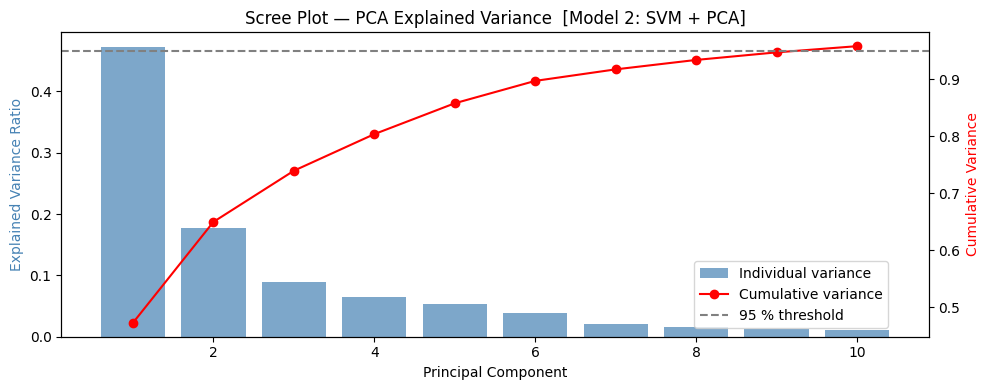

In [11]:
# ------ MODEL 2: SVM + PCA — SCREE PLOT ------ 
# Shows how much variance each principal component explains.

cumulative = np.cumsum(pca_95.explained_variance_ratio_)

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(range(1, pca_95.n_components_ + 1),
        pca_95.explained_variance_ratio_,
        color='steelblue', alpha=0.7, label='Individual variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(1, pca_95.n_components_ + 1),
         cumulative, 'ro-', label='Cumulative variance')
ax2.axhline(y=0.95, color='gray', linestyle='--', label='95 % threshold')
ax2.set_ylabel('Cumulative Variance', color='red')

plt.title('Scree Plot — PCA Explained Variance  [Model 2: SVM + PCA]')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.show()


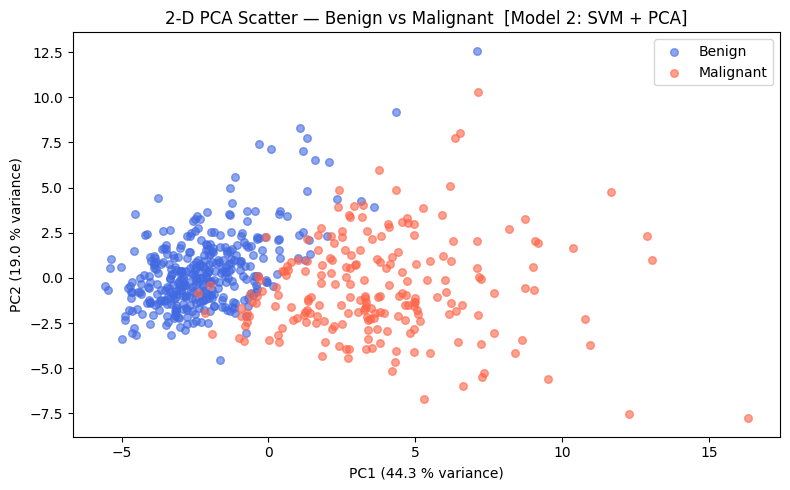

In [12]:
# ------ MODEL 2: SVM + PCA — 2-D PCA SCATTER ------ 
# Visualises class separability by projecting 30 features into 2 dimensions.

pca_2d   = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
for label, name, color in [(0, 'Benign', 'royalblue'), (1, 'Malignant', 'tomato')]:
    mask = (y == label)
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=name, color=color, alpha=0.6, s=30)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f} % variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f} % variance)')
plt.title('2-D PCA Scatter — Benign vs Malignant  [Model 2: SVM + PCA]')
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# ------------- MODEL 2: SVM + PCA — TRAIN SVM ------------- 
# kernel='rbf' : Radial Basis Function — maps data to higher-dimensional space.
# C=1.0        : Regularisation strength.
# gamma='scale': 1 / (n_features * X.var()) — sensible default.

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale',
                probability=True, random_state=42)
svm_model.fit(X_pca_train, y_train)

print('[Model 2 — SVM + PCA] Training complete.')


[Model 2 — SVM + PCA] Training complete.


In [14]:
# ------ MODEL 2: SVM + PCA — EVALUATE (VAL + TEST) ------

# Validation
y_val_pred_svm = svm_model.predict(X_pca_val)
svm_val_acc, svm_val_prec, svm_val_rec, svm_val_f1 = print_metrics(
    'Model 2 — SVM + PCA', y_val, y_val_pred_svm, 'Validation'
)

# Test
y_pred_svm = svm_model.predict(X_pca_test)
svm_acc, svm_prec, svm_rec, svm_f1 = print_metrics(
    'Model 2 — SVM + PCA', y_test, y_pred_svm, 'Test'
)


[Model 2 — SVM + PCA] Validation Set
  Accuracy  : 0.9123
  Precision : 0.9714
  Recall    : 0.7907
  F1-score  : 0.8718

[Model 2 — SVM + PCA] Test Set
  Accuracy  : 0.9737
  Precision : 0.9756
  Recall    : 0.9524
  F1-score  : 0.9639



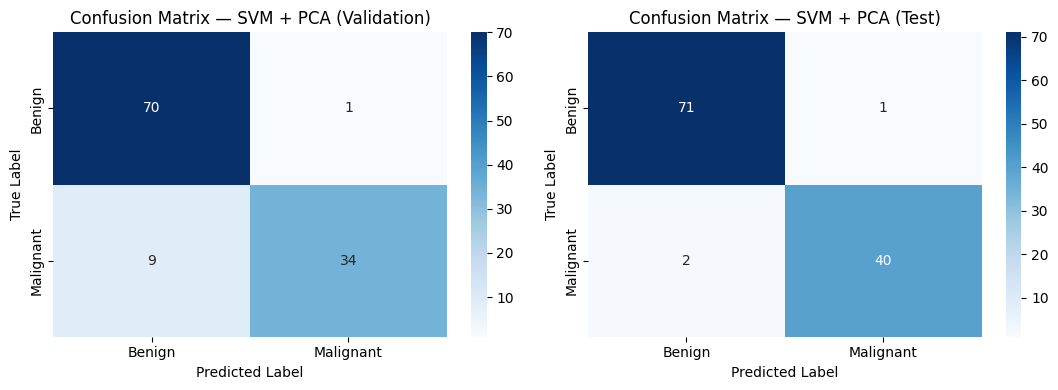

In [15]:
# ------ MODEL 2: SVM + PCA — CONFUSION MATRIX (VAL & TEST) ------

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_val,  y_test],
    [y_val_pred_svm, y_pred_svm],
    ['Validation', 'Test']
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'Confusion Matrix — SVM + PCA ({title})')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()


In [16]:
# ----- MODEL 2: SVM + PCA — CROSS-VALIDATION ----- 

svm_cv = cross_val_score(
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    X_pca_all, y, cv=5
)

print('[Model 2 — SVM + PCA] 5-Fold Cross-Validation')
print(f'  CV scores : {svm_cv}')
print(f'  Mean CV   : {svm_cv.mean():.4f}')


[Model 2 — SVM + PCA] 5-Fold Cross-Validation
  CV scores : [0.96491228 0.97368421 0.97368421 0.96491228 1.        ]
  Mean CV   : 0.9754


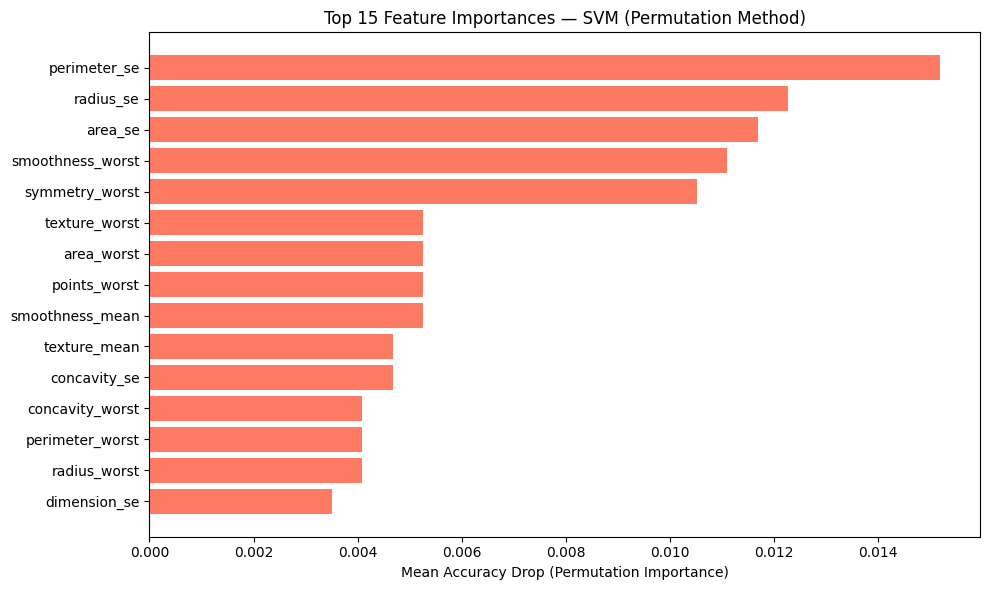

In [17]:
# --------- MODEL 2: SVM + PCA — FEATURE IMPORTANCE (Permutation) --------- 
# SVMs have no direct coefficients, so we use permutation importance:
# shuffle one feature at a time and measure accuracy drop.
# Trained on original (non-PCA) scaled data so names map back to features.

svm_orig = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_orig.fit(X_train_scaled, y_train)

perm_result = permutation_importance(
    svm_orig, X_test_scaled, y_test,
    n_repeats=15, random_state=42, scoring='accuracy'
)

importances_svm = perm_result.importances_mean
sorted_idx_svm  = np.argsort(importances_svm)[::-1]
top_n           = 15

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in sorted_idx_svm[:top_n]][::-1],
    importances_svm[sorted_idx_svm[:top_n]][::-1],
    color='tomato', alpha=0.85
)
plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title(f'Top {top_n} Feature Importances — SVM (Permutation Method)')
plt.tight_layout()
plt.show()


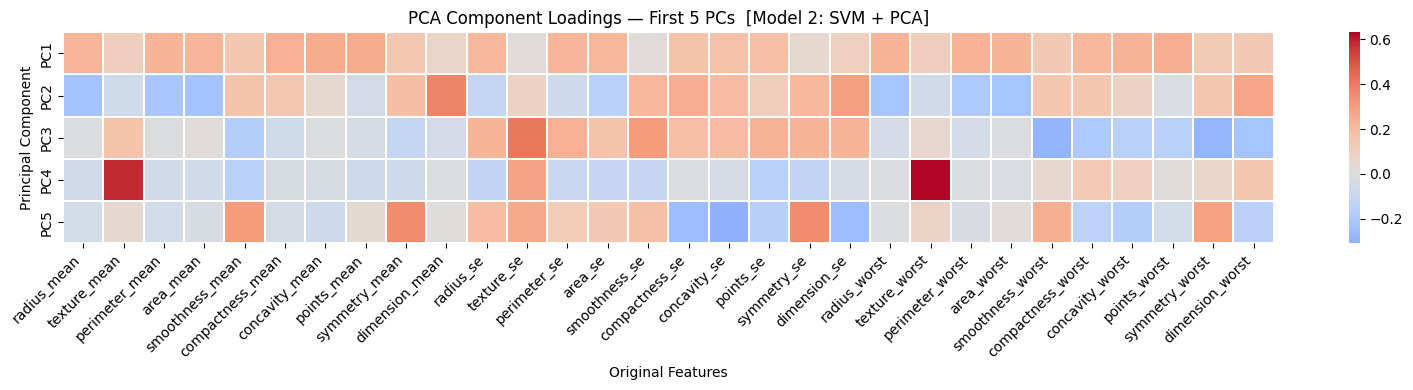

In [18]:
# ------ MODEL 2: SVM + PCA — PCA COMPONENT LOADINGS HEATMAP ------ 
# Shows which original features each principal component captures most.
# Positive loading = feature increases along that PC axis; negative = decreases.

components_df = pd.DataFrame(
    pca_95.components_[:5],
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(5)]
)

plt.figure(figsize=(16, 4))
sns.heatmap(components_df, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
plt.title('PCA Component Loadings — First 5 PCs  [Model 2: SVM + PCA]')
plt.xlabel('Original Features')
plt.ylabel('Principal Component')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


[Model 3 — KNN] Best k found: 7  (mean CV = 0.9684)


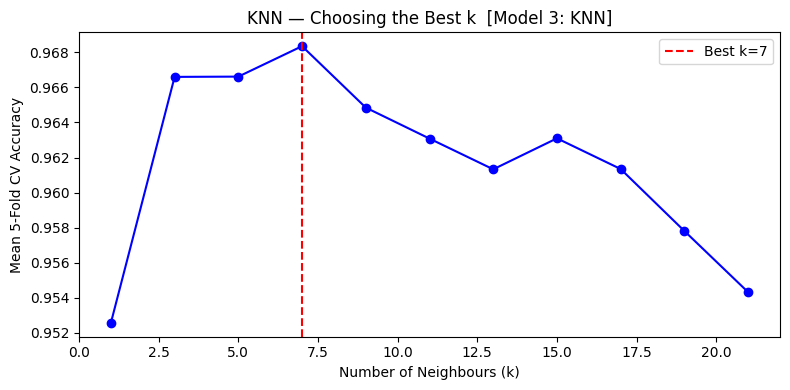

In [19]:
# ------- MODEL 3: KNN — SELECT BEST K -------
# Test odd values of k from 1 to 21 using 5-fold CV to avoid ties.
# We pick the k with the highest mean CV accuracy.

k_values  = range(1, 22, 2)   # 1, 3, 5, ..., 21  (odd values only)
cv_means  = []

for k in k_values:
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_scaled, y, cv=5
    )
    cv_means.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_means)]
print(f'[Model 3 — KNN] Best k found: {best_k}  (mean CV = {max(cv_means):.4f})')

# Plot k vs CV accuracy
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), cv_means, 'bo-', linewidth=1.5)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Mean 5-Fold CV Accuracy')
plt.title('KNN — Choosing the Best k  [Model 3: KNN]')
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
# ------- MODEL 3: KNN — TRAIN -------

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

print(f'[Model 3 — KNN] Training complete with k={best_k}.')


[Model 3 — KNN] Training complete with k=7.


In [21]:
# --------- MODEL 3: KNN — EVALUATE (VAL + TEST) ---------

# Validation
y_val_pred_knn = knn_model.predict(X_val_scaled)
knn_val_acc, knn_val_prec, knn_val_rec, knn_val_f1 = print_metrics(
    'Model 3 — KNN', y_val, y_val_pred_knn, 'Validation'
)

# Test
y_pred_knn = knn_model.predict(X_test_scaled)
knn_acc, knn_prec, knn_rec, knn_f1 = print_metrics(
    'Model 3 — KNN', y_test, y_pred_knn, 'Test'
)


[Model 3 — KNN] Validation Set
  Accuracy  : 0.9211
  Precision : 1.0000
  Recall    : 0.7907
  F1-score  : 0.8831

[Model 3 — KNN] Test Set
  Accuracy  : 0.9825
  Precision : 1.0000
  Recall    : 0.9524
  F1-score  : 0.9756



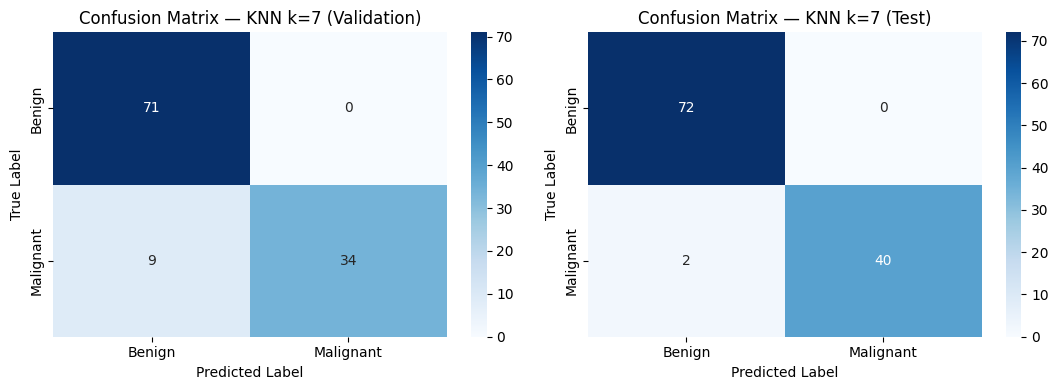

In [22]:
# ------- MODEL 3: KNN — CONFUSION MATRIX (VAL & TEST) -------

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_val,  y_test],
    [y_val_pred_knn, y_pred_knn],
    ['Validation', 'Test']
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'Confusion Matrix — KNN k={best_k} ({title})')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()


In [23]:
# ----- MODEL 3: KNN — CROSS-VALIDATION ----- 

cv_scores_knn = cross_val_score(
    KNeighborsClassifier(n_neighbors=best_k),
    X_scaled, y, cv=5
)

print('[Model 3 — KNN] 5-Fold Cross-Validation')
print(f'  CV scores : {cv_scores_knn}')
print(f'  Mean CV   : {cv_scores_knn.mean():.4f}')


[Model 3 — KNN] 5-Fold Cross-Validation
  CV scores : [0.93859649 0.96491228 0.99122807 0.98245614 0.96460177]
  Mean CV   : 0.9684


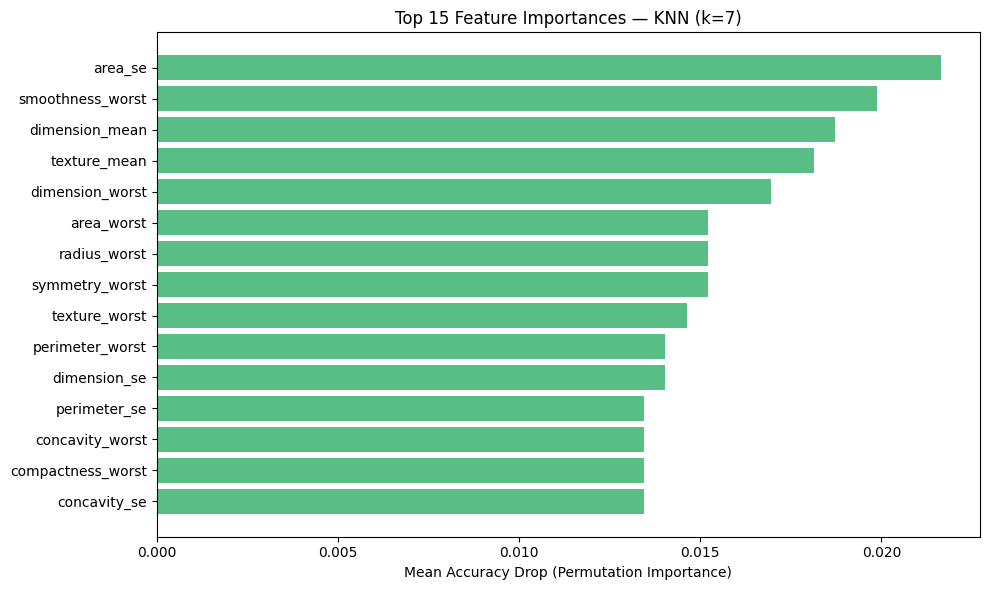

In [24]:
# ------ MODEL 3: KNN — FEATURE IMPORTANCE (Permutation) ------ 
# KNN has no built-in coefficients, so we use permutation importance.

perm_knn = permutation_importance(
    knn_model, X_test_scaled, y_test,
    n_repeats=15, random_state=42, scoring='accuracy'
)

importances_knn = perm_knn.importances_mean
sorted_idx_knn  = np.argsort(importances_knn)[::-1]
top_n           = 15

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in sorted_idx_knn[:top_n]][::-1],
    importances_knn[sorted_idx_knn[:top_n]][::-1],
    color='mediumseagreen', alpha=0.85
)
plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title(f'Top {top_n} Feature Importances — KNN (k={best_k})')
plt.tight_layout()
plt.show()


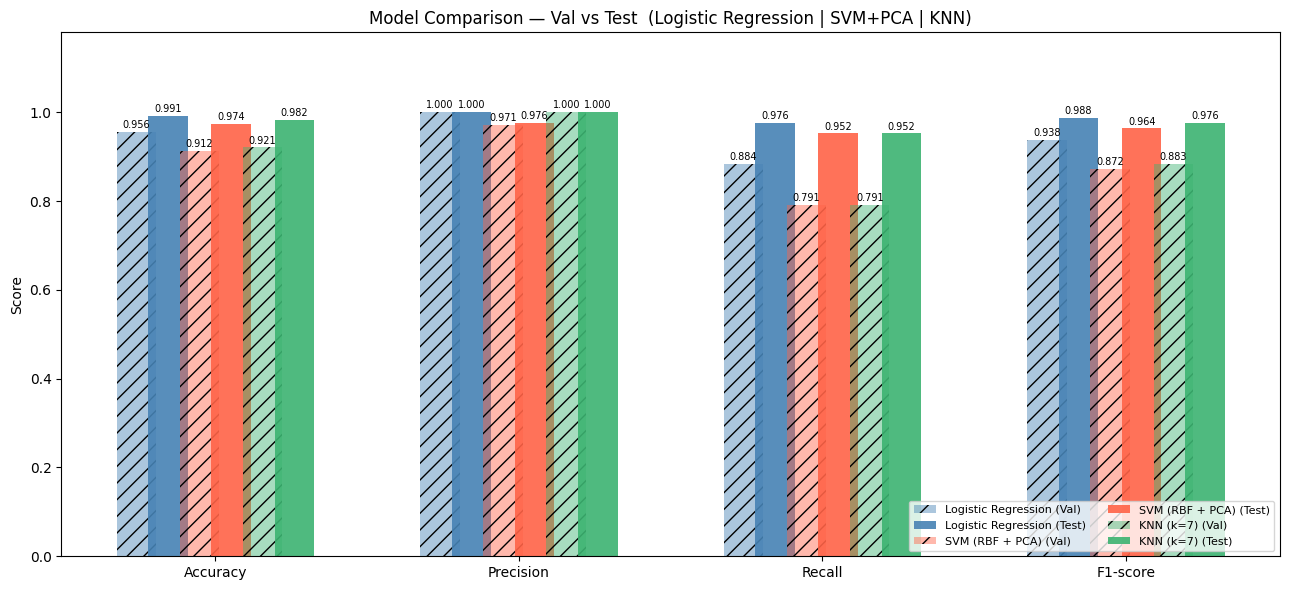

In [25]:
# ----- STEP 5: MODEL COMPARISON — VALIDATION vs TEST BAR CHART ----- 
# Each metric shows two bars per model: Validation (lighter) and Test (solid).

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

val_scores  = {
    'Logistic Regression': [lr_val_acc,  lr_val_prec,  lr_val_rec,  lr_val_f1],
    'SVM (RBF + PCA)'    : [svm_val_acc, svm_val_prec, svm_val_rec, svm_val_f1],
    f'KNN (k={best_k})'  : [knn_val_acc, knn_val_prec, knn_val_rec, knn_val_f1],
}
test_scores = {
    'Logistic Regression': [lr_acc,  lr_prec,  lr_rec,  lr_f1],
    'SVM (RBF + PCA)'    : [svm_acc, svm_prec, svm_rec, svm_f1],
    f'KNN (k={best_k})'  : [knn_acc, knn_prec, knn_rec, knn_f1],
}

colors = {'Logistic Regression': 'steelblue',
          'SVM (RBF + PCA)'    : 'tomato',
          f'KNN (k={best_k})'  : 'mediumseagreen'}

x      = np.arange(len(metrics))
n_models = len(val_scores)
width  = 0.13
offsets = np.linspace(-(n_models - 1) * width, (n_models - 1) * width, n_models * 2)

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, color) in enumerate(colors.items()):
    v_bars = ax.bar(x + offsets[i*2],   val_scores[model_name],  width,
                    label=f'{model_name} (Val)',  color=color, alpha=0.45, hatch='//')
    t_bars = ax.bar(x + offsets[i*2+1], test_scores[model_name], width,
                    label=f'{model_name} (Test)', color=color, alpha=0.90)
    for bars in [v_bars, t_bars]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.004,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Val vs Test  (Logistic Regression | SVM+PCA | KNN)')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


In [26]:
# ----- STEP 5: MODEL COMPARISON — SUMMARY TABLE -----

model_names = ['Logistic Regression', 'SVM (RBF + PCA)', f'KNN (k={best_k})']

val_f1_scores  = [lr_val_f1,  svm_val_f1,  knn_val_f1]
test_f1_scores = [lr_f1,      svm_f1,      knn_f1]

header = f"{'Metric':<15} {'Split':<12} {'Log. Regression':>18} {'SVM+PCA':>12} {'KNN':>10}"
print('\n' + '='*75)
print('                    FINAL MODEL COMPARISON SUMMARY')
print('='*75)
print(header)
print('-'*75)

all_val  = [val_scores[m]  for m in model_names]
all_test = [test_scores[m] for m in model_names]

for mi, metric in enumerate(metrics):
    v = [all_val[j][mi]  for j in range(3)]
    t = [all_test[j][mi] for j in range(3)]
    print(f"{metric:<15} {'Validation':<12} {v[0]:>18.4f} {v[1]:>12.4f} {v[2]:>10.4f}")
    print(f"{'':15} {'Test':<12} {t[0]:>18.4f} {t[1]:>12.4f} {t[2]:>10.4f}")
    print('-'*75)

print('='*75)

# Pick winner by Test F1 (best metric for imbalanced medical data)
winner_idx = np.argmax(test_f1_scores)
print(f'\nBest model by Test F1-score: {model_names[winner_idx]}')



                    FINAL MODEL COMPARISON SUMMARY
Metric          Split           Log. Regression      SVM+PCA        KNN
---------------------------------------------------------------------------
Accuracy        Validation               0.9561       0.9123     0.9211
                Test                     0.9912       0.9737     0.9825
---------------------------------------------------------------------------
Precision       Validation               1.0000       0.9714     1.0000
                Test                     1.0000       0.9756     1.0000
---------------------------------------------------------------------------
Recall          Validation               0.8837       0.7907     0.7907
                Test                     0.9762       0.9524     0.9524
---------------------------------------------------------------------------
F1-score        Validation               0.9383       0.8718     0.8831
                Test                     0.9880       0.9639     0.9


FINAL MODEL: CONFUSION MATRIX & FEATURE IMPORTANCE


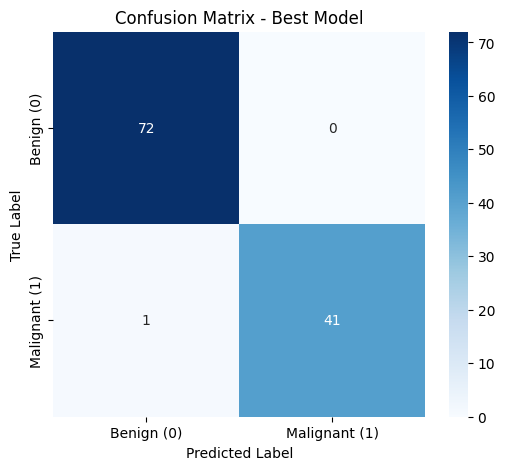

In [28]:
best_model = lr_model  # Change this to your actual best model (e.g., svc_model or knn_model)
y_pred_best = y_pred_lr # Change to the respective predictions

print('\n' + '='*75)
print('FINAL MODEL: CONFUSION MATRIX & FEATURE IMPORTANCE')
print('='*75)

# 1. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
